In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import moment
import matplotlib.pyplot as plt

In [66]:
df = pd.read_csv("C:/Users/Sven Jacob/Desktop/ICML/High_Dimensional_Online__Supplementary Material/CODE_SWCPD/ChangeDetection/datasets/Occupancy/Occupancy.csv").iloc[:,1:]

In [67]:
df_scaled = (df - df.mean())/df.std()

In [69]:
X = df_scaled.values
moment(X,order=3)

tmp_moments = []
dataloader = DataLoader(TimeseriesDataset(X,500,split=0.5))
for i, d in enumerate(dataloader):
    x_ref, x_cur = d[0].squeeze(0).cpu().numpy(), d[1].squeeze(0).cpu().numpy()
    tmp_moments.append(np.abs(moment(x_ref,order=3)).max())

print({'max':max(tmp_moments),'mean':np.mean(tmp_moments),'median':np.median(tmp_moments),'max':max(tmp_moments),'operator_norm': np.linalg.svd(pd.DataFrame(x_ref).cov().values,full_matrices=False,compute_uv=False)[0]})

{'max': 3.725126239179156, 'mean': 0.32902814599106045, 'median': 0.02764296994849102, 'operator_norm': 0.004382579629375754}


In [26]:
df = np.loadtxt("C:/Users/Sven Jacob/Desktop/ICML/High_Dimensional_Online__Supplementary Material/CODE_SWCPD/ChangeDetection/datasets/HAR_NEW/UCI HAR Dataset/train/X_train.txt")

HAR NEW

In [2]:
DATAPATH = "C:/Users/Sven Jacob/Desktop/ICML/High_Dimensional_Online__Supplementary Material/CODE_SWCPD/ChangeDetection/datasets"

In [101]:
X_train = np.loadtxt(f'{DATAPATH}/HAR_NEW/UCI HAR Dataset/train/X_train.txt')  

y_train = np.loadtxt(f"{DATAPATH}/HAR_NEW/UCI HAR Dataset/train/y_train.txt")

human = np.loadtxt(f"{DATAPATH}/HAR_NEW/UCI HAR Dataset/train/subject_train.txt")


X_test = np.loadtxt(f"{DATAPATH}/HAR_NEW/UCI HAR Dataset/test/X_test.txt")

y_test = np.loadtxt(f"{DATAPATH}/HAR_NEW/UCI HAR Dataset/test/y_test.txt")

human_test = np.loadtxt(f"{DATAPATH}/HAR_NEW/UCI HAR Dataset/test/subject_test.txt")

In [102]:
df_train = pd.DataFrame(X_train)
df_train['state']  =y_train
df_train['human'] = human.astype(int)

df_test = pd.DataFrame(X_test)
df_test['state']  =y_test
df_test['human'] = human_test.astype(int)

In [5]:
for human in df_train['human'].unique():
    tmp = df_train[df_train['human']==human]
    tmp = tmp.reset_index(drop=True)
    
    GroundTruth = tmp.index[tmp.iloc[:,-2].diff()!=0][1:]+1

    data = tmp.iloc[:,:-2].values.astype(np.float32)
    data = (data-np.mean(data))/np.std(data)
    print(max(np.abs(moment(data,order=3))))
for human in df_test['human'].unique():
    tmp = df_test[df_test['human']==human]
    tmp = tmp.reset_index(drop=True)
    
    GroundTruth = tmp.index[tmp.iloc[:,-2].diff()!=0][1:]+1

    data = tmp.iloc[:,:-2].values.astype(np.float32)
    data = (data-np.mean(data))/np.std(data)
    print(max(np.abs(moment(data,order=3))))

2.8939276
3.4723465
4.0376186
3.7789664
3.5679488
2.9462118
3.0671332
1.6249584
3.2822332
3.0863438
3.0789688
1.9417121
2.4734812
3.1422734
3.2812169
3.3780053
3.4723125
3.3798108
3.5830648
3.81083
3.897139
2.8420517
3.9520714
3.810997
3.4445016
4.1455817
2.94862
3.4008508
2.8897953
4.0346727


In [103]:
from torch.utils.data import DataLoader
import torch 
class TimeseriesDataset(torch.utils.data.Dataset):   
    def __init__(self, X, seq_len=10,split=0.5):
        self.X = X
        #self.y = y
        self.seq_len = seq_len
        self.split = split

    def __len__(self):
        return self.X.__len__() - (self.seq_len-1)

    def __getitem__(self, index):
        window = index + int(self.seq_len*self.split)
        #print(index,window)
        #self.seq_len - int(self.seq_len//2)
        #print(window)
        return (self.X[index:window],self.X[window:window+ int(self.seq_len*(1-self.split))])

c:\Users\Sven Jacob\miniconda3\envs\torch\Lib\site-packages\scipy\_lib\_util.py:798: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return fun(*args, **kwargs)


Text(0, 0.5, '')

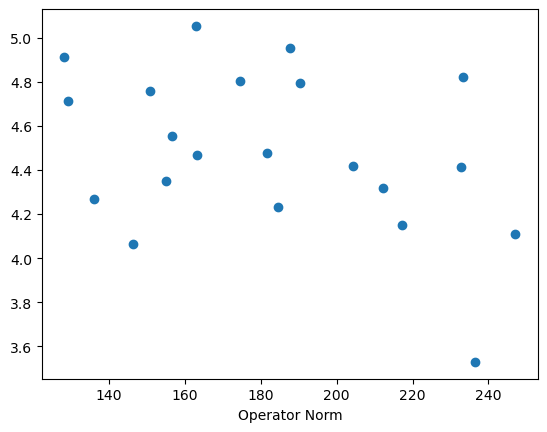

In [105]:
X_Moments = {}

for human in df_train['human'].unique():
    tmp = df_train[df_train['human']==human]
    tmp = tmp.reset_index(drop=True)
        
    data = tmp.iloc[:,:-2].values.astype(np.float32)
    data = (data-np.mean(data))/np.std(data)
    tmp_moments = []
    tmp_op_norm = []
    dataloader = DataLoader(TimeseriesDataset(data,20,split=0.5))
    for i, d in enumerate(dataloader):
        x_ref, x_cur = d[0].squeeze(0).cpu().numpy(), d[1].squeeze(0).cpu().numpy()
        tmp_moments.append(np.abs(moment(x_ref,order=3)).max())
        tmp_op_norm.append(np.linalg.svd(pd.DataFrame(x_ref).cov().values,full_matrices=False,compute_uv=False)[0])
        #Y_Moments.append(np.abs(moment(x_cur,order=3)).max())

    X_Moments[human] = {'max':max(tmp_moments),'mean':np.mean(tmp_moments),'median':np.median(tmp_moments),'max':max(tmp_moments),'operator_norm': max(tmp_op_norm)}



op_norm = []
max_third_moment = []
for k,vals in X_Moments.items():
    op_norm.append(vals.get('operator_norm'))
    max_third_moment.append(vals.get('max'))
plt.scatter(op_norm, max_third_moment)
plt.xlabel('Operator Norm')
plt.ylabel('')



In [106]:
for k,vals in X_Moments.items():
    print(vals.get('max'))

4.951816
4.466123
4.8025236
4.416747
4.821251
4.107494
4.063433
4.4754896
4.351958
4.914042
4.7586064
3.5291533
4.3197813
4.148765
4.4148703
4.7116127
4.270602
4.5552444
5.0538936
4.230489
4.7952375


In [112]:
import zipfile
import json

zip_file_path = f'{DATAPATH}/MNISTSeq.zip'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_contents = zip_ref.namelist()
    json_file_name = zip_contents[0]
    with zip_ref.open(json_file_name) as json_file:
        data = json.load(json_file)

In [113]:
X_Moments = {}

for id, k in enumerate(data.keys()):
    ground_truths = data[k]['target']
    ts = np.array(data[k]['data'])
    n = ground_truths[-1] + 200
    tmp_moments  =[]
    tmp_op_norm = []
    dataloader = DataLoader(TimeseriesDataset(ts,50,split=0.5))
    for i, d in enumerate(dataloader):
        x_ref, x_cur = d[0].squeeze(0).cpu().numpy(), d[1].squeeze(0).cpu().numpy()
        tmp_moments.append(np.abs(moment(x_ref,order=3)).max())
        #Y_Moments.append(np.abs(moment(x_cur,order=3)).max())
        tmp_op_norm.append(np.linalg.svd(pd.DataFrame(x_ref).cov().values,full_matrices=False,compute_uv=False)[0])

    X_Moments[id] = {'max':max(tmp_moments),'mean':np.mean(tmp_moments),'median':np.median(tmp_moments),'max':max(tmp_moments),'operator_norm': max(tmp_op_norm)}


In [115]:
for k,vals in X_Moments.items():
    print(vals.get('max'))

0.0957754737766058
0.09442925002529258
0.0957754737766058
0.09443219231410728
0.0957754737766058
0.0957754737766058
0.0957754737766058
0.0957754737766058
0.0957754737766058
0.09443219231410728
0.0957754737766058
0.0957754737766058
0.0957754737766058
0.09443219231410728
0.0957754737766058


In [126]:
s = 10
(np.exp(s)+2)*np.sqrt(s-1)

66085.39738442015

In [74]:
import os

In [108]:
for file in os.listdir(f"{DATAPATH}/has2023DataR"):
    if file.endswith('.csv'):
        data = pd.read_csv(f"{DATAPATH}/has2023DataR/{file}").iloc[:,1:]
        tmp_op_norm = []
        tmp_moments  =[]
        dataloader = DataLoader(TimeseriesDataset(data.values,500,split=0.5))
        try:
            for i, d in enumerate(dataloader):
                x_ref, x_cur = d[0].squeeze(0).cpu().numpy(), d[1].squeeze(0).cpu().numpy()
                tmp_moments.append(np.abs(moment(x_ref,order=3)).max())
                #Y_Moments.append(np.abs(moment(x_cur,order=3)).max())
                tmp_op_norm.append(np.linalg.svd(pd.DataFrame(x_ref).cov().values,full_matrices=False,compute_uv=False)[0])

            X_Moments[file] = {'max':max(tmp_moments),'mean':np.mean(tmp_moments),'median':np.median(tmp_moments),'max':max(tmp_moments),'operator_norm': max(tmp_op_norm) }
        except:
            continue

print(X_Moments)
op_norm = []
for k,vals in X_Moments.items():
    op_norm.append(vals.get('operator_norm'))


{1: {'max': 4.951816, 'mean': 1.8931252, 'median': 1.8233409, 'operator_norm': 187.80690323297614}, 3: {'max': 4.466123, 'mean': 2.166355, 'median': 2.083326, 'operator_norm': 163.25202099150846}, 5: {'max': 4.8025236, 'mean': 2.0250244, 'median': 1.7830712, 'operator_norm': 174.44254785980817}, 6: {'max': 4.416747, 'mean': 1.8842207, 'median': 1.6998354, 'operator_norm': 204.24802720190635}, 7: {'max': 4.821251, 'mean': 1.8508271, 'median': 1.6365788, 'operator_norm': 233.3405511047034}, 8: {'max': 4.107494, 'mean': 1.8872256, 'median': 1.8436651, 'operator_norm': 247.10442404382522}, 11: {'max': 4.063433, 'mean': 1.9119124, 'median': 1.8325039, 'operator_norm': 146.30320120602502}, 14: {'max': 4.4754896, 'mean': 1.6880718, 'median': 1.56353, 'operator_norm': 181.71682719406888}, 15: {'max': 4.351958, 'mean': 1.9020083, 'median': 1.7491777, 'operator_norm': 155.01306070557973}, 16: {'max': 4.914042, 'mean': 1.8346468, 'median': 1.6243849, 'operator_norm': 128.20168753190868}, 17: {'ma

In [111]:
for k,vals in X_Moments.items():
    print(vals.get('operator_norm'))

187.80690323297614
163.25202099150846
174.44254785980817
204.24802720190635
233.3405511047034
247.10442404382522
146.30320120602502
181.71682719406888
155.01306070557973
128.20168753190868
150.9062434171745
236.3646846975922
212.3143105498029
217.32740080671527
232.7923692293205
129.10298842732777
136.10918378926436
156.47683949765707
162.99296008497154
184.4250785701663
190.40915539060938
4.718845206106932
3.0471084043341508
7.586174938735143
5.833740941575934
21.4913035691348
4.920016079422321
5.713138262240789
4.500704615859702
5.945995206894435
5.995494247781649
7.151814018940158
6.158358376760557
6.35926211558117
4.336958183225535
12.25267181902192
7.595866753412614
12.192594926644407
4.730403884108685
3.7997102666905924
11.643763110017634
6.3398890974366635


In [ ]:
op_norm = []
max_third_moment = []
for k,vals in X_Moments.items():
    op_norm.append(vals.get('operator_norm'))
    max_third_moment.append(vals.get('max'))
plt.scatter(op_norm, max_third_moment)

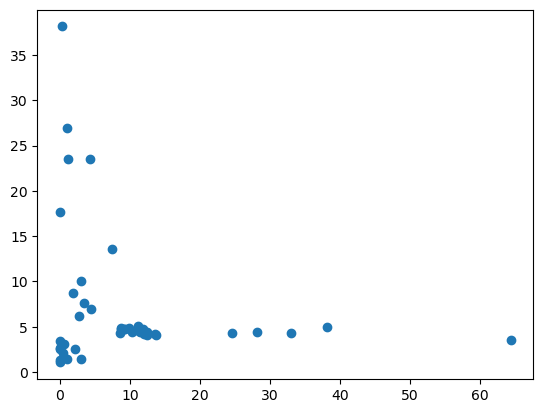

In [100]:
plt.scatter(op_norm, max_third_moment)